##Basic Imports and loading

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
# Load and prepare data
df = pd.read_excel('GenAI Survey.xlsx', sheet_name='Form Responses 1')

# Clean column names
df.columns = df.columns.str.replace('\n', ' ').str.strip()

##Basic Survey Statistics

In [ ]:
likert_mapping = {
    'Strongly agree': 5,
    'Agree': 4,
    'Neutral': 3,
    'Disagree': 2,
    'Strongly Disagree': 1
}
environmental_col = 'The environmental impact of AI influences how I use GenAI tools.'
bias_col = 'I am aware of and cautious of potential racial, gender-based and other such biases that AI models can get corrupted by.'

In [ ]:
def transform_age_groups(age):
    if pd.isna(age):
        return None
    if age in ['<18', '18 to 24']:
        return '<25'
    elif age in ['35 to 54']:
        return '25-54'
    elif age in ['55 to 64', '65<'] or '65' in str(age):
        return '>55'
    return age

In [ ]:
df['User'] = df["Do you use GenAI tools? Note: if you answer 'No', skip over to the next section and only answer questions marked as required."].map({'Yes': 1, 'No': 0})
df['Efficiency'] = df['GenAI increases my productivity.'].map(likert_mapping)
df['Ease of Use'] = df['I am able to frame prompts easily.'].map(likert_mapping)
df['Trust'] = df['I trust AI generated responses and content.'].map(likert_mapping)
df['Environmental Impact'] = df[environmental_col].map(likert_mapping)
df['Bias Awareness'] = df[bias_col].map(likert_mapping)
df['Perceived Social Impact'] = df['I believe that GenAI tools negatively impact society.'].map(likert_mapping)


In [ ]:
df['Age Group'] = df['Age Group'].apply(transform_age_groups).dropna()

In [ ]:
df['Performance Expectancy'] = df['GenAI enhances the quality of my work.'].map(likert_mapping)
df['Effort Expectancy'] = df['GenAI increases my productivity.'].map(likert_mapping)
df['Social Influence'] = df['I use GenAI tools because everybody around me is using them.'].map(likert_mapping)

In [ ]:
df['Frequent Usage'] = df['When did you last use a GenAI tool?'].apply(lambda x: 1 if x in ['Today', 'This week'] else 0)

In [ ]:
df['Ethical Concerns'] = df[['Environmental Impact', 'Bias Awareness']].mean(axis = 1)

In [ ]:
df['Gender Coded'] = df['Gender'].apply(lambda x: 1 if x in ['Male'] else 0)

In [ ]:
df[['Efficiency', 'Ease of Use', 'Ethical Concerns', 'Trust', 'Performance Expectancy', 'Effort Expectancy', 'Perceived Social Impact' , 'Frequent Usage']]= df[['Efficiency', 'Ease of Use', 'Ethical Concerns', 'Trust', 'Performance Expectancy', 'Effort Expectancy', 'Perceived Social Impact' , 'Frequent Usage']].fillna(0)

In [ ]:
for col in ['Efficiency', 'Ease of Use',
            'Ethical Concerns', 'Trust', 'Performance Expectancy', 'Effort Expectancy',
            'Perceived Social Impact', 'Social Influence']:
  print(df[col].value_counts())

for col in ['User', 'Gender Coded', 'Frequent Usage']:
  print(df[col].value_counts())

Efficiency
5.0    31
4.0    23
3.0    12
0.0     7
1.0     1
Name: count, dtype: int64
Ease of Use
4.0    29
5.0    18
3.0    17
0.0     7
2.0     3
Name: count, dtype: int64
Ethical Concerns
3.5    20
3.0    19
4.0    18
4.5     7
2.5     5
5.0     4
2.0     1
Name: count, dtype: int64
Trust
3    38
4    20
2    10
1     4
5     2
Name: count, dtype: int64
Performance Expectancy
4.0    28
5.0    22
3.0    14
0.0     7
2.0     2
1.0     1
Name: count, dtype: int64
Effort Expectancy
5.0    31
4.0    23
3.0    12
0.0     7
1.0     1
Name: count, dtype: int64
Perceived Social Impact
2    25
3    24
4    14
1     6
5     5
Name: count, dtype: int64
Social Influence
2.0    26
3.0    18
4.0    11
1.0     8
5.0     4
Name: count, dtype: int64
User
1    61
0    13
Name: count, dtype: int64
Gender Coded
1    47
0    27
Name: count, dtype: int64
Frequent Usage
1    53
0    21
Name: count, dtype: int64


##EDA

 - Age-wise how many use GenAI vs how many don't
 - Gender-wise how many use GenAI vs how many don't
 - No. of users per tool
 - Correlation matrix of the factors being used

In [ ]:
df['Use Cases'] = df['What do you primarily use GenAI for?'].str.split(', ')
df['Tools'] = df['What GenAI tools do you normally use?'].str.split(', ')

In [ ]:
usage_counts = df.groupby(['Age Group', 'User']).size().unstack()
usage_counts

User,0,1
Age Group,,
25-54,2,28
<25,2,30
>55,9,3


In [ ]:
usage_counts_g = df.groupby(['Gender', 'User']).size().unstack()
usage_counts_g

User,0,1
Gender,,
Female,5,22
Male,8,39


In [ ]:
df['Frequent Usage'].value_counts()

,count
Frequent Usage,
1,53
0,21


In [ ]:
df['Tools'].value_counts()

,count
Tools,
ChatGPT,125
Github Copilot,41
Perplexity,38
Other,29
DeepSeek,24
Claude,20


##Some Visuals

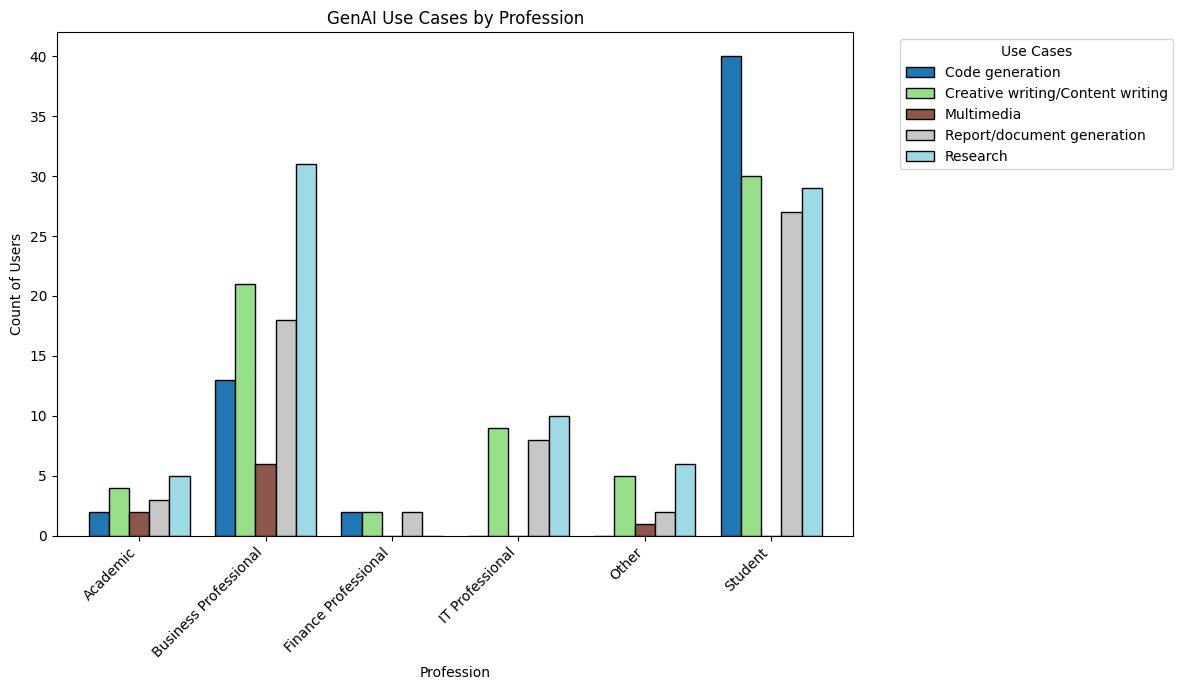

In [ ]:


# Figure 1: Profession vs Use Cases
prof_use = df.groupby(['Profession', 'Use Cases']).size().unstack()
prof_use.plot(kind='bar',
                   figsize=(12,7),
                   width=0.8,
                   cmap='tab20',
                   edgecolor='black')
plt.title('GenAI Use Cases by Profession')
plt.ylabel('Count of Users')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Use Cases', bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()


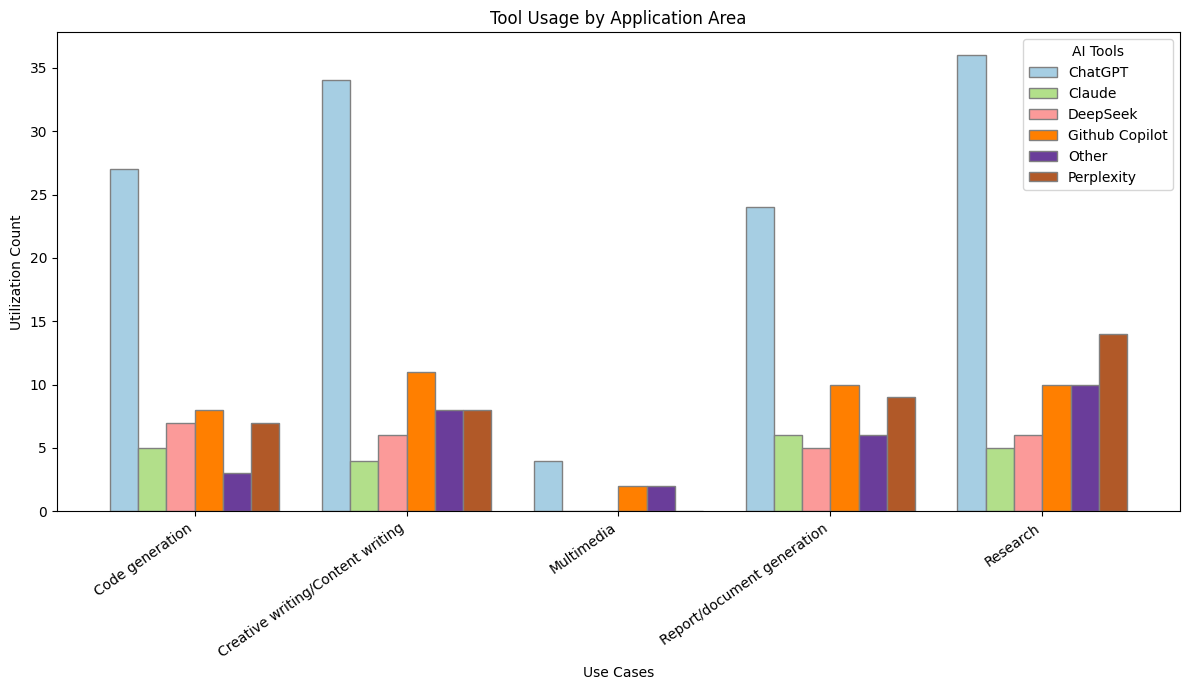

In [ ]:
use_tool = df.groupby(['Use Cases', 'Tools']).size().unstack()
use_tool.plot(kind='bar',
                  figsize=(12,7),
                  width=0.8,
                  colormap='Paired',
                  edgecolor='gray')
plt.title('Tool Usage by Application Area')
plt.ylabel('Utilization Count')
plt.xticks(rotation=35, ha='right')
plt.legend(title='AI Tools')
plt.tight_layout()

##Logistic Regression basic imports

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:
# Correct column name with trailing space
premium_col = 'Do you have a premium version of any of these tools?'

# Create ethical concerns composite feature


##Logistic Regression Model: Frequency of Usage

In [ ]:
cols = ['Efficiency', 'Ease of Use', 'Trust', 'Environmental Impact', 'Bias Awareness']
df[cols] = df[cols].fillna(0)

In [ ]:
df[premium_col] =df[premium_col].fillna('No')

In [ ]:
df['Frequent Usage'].value_counts()

,count
Frequent Usage,
1,53
0,21


In [ ]:
from sklearn.preprocessing import OneHotEncoder


In [ ]:
X = df[['Efficiency', 'Ease of Use', 'Ethical Concerns', 'Trust', 'Performance Expectancy', 'Effort Expectancy', 'Perceived Social Impact' ]]
y = df['Frequent Usage']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# try running without train test split too

In [ ]:
logreg = LogisticRegression(class_weight = 'balanced')
model = logreg.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(f"Accuracy: {model.score(X_test, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.87
ROC-AUC: 0.88

Confusion Matrix:
[[ 5  2]
 [ 1 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.88      0.94      0.91        16

    accuracy                           0.87        23
   macro avg       0.86      0.83      0.84        23
weighted avg       0.87      0.87      0.87        23



The model has 87% accuracy, with 88% precision and 94% recall for predicting class 1 (frequent GenAi users), and 83% precision and 71% recall for predicting class 0 (infrequent users).

The ROC-AUC score is 0.88, indicating that the model is a good fit.

In [ ]:
coefficients = pd.Series(model.coef_[0], index=X.columns)
print("\nFeature Coefficients:")
print(coefficients.sort_values(ascending=False))


Feature Coefficients:
Performance Expectancy     1.144542
Ease of Use                0.879782
Ethical Concerns           0.138408
Effort Expectancy         -0.133063
Efficiency                -0.133063
Perceived Social Impact   -0.148611
Trust                     -0.463327
dtype: float64


Interpretation:
- Performance expectancy, ease of use and trust have the largest weights in the logistic regression model.
- There is a negative relationship between trust and frequency of usage, indicating that despite mistrust of AI-generated responses, respondents still use the tools frequently.
- Perceived social impact also moderately negatively influence likelihood of subsscription.

##ANOVA: Age group against 'Performance Expectancy', 'Effort Expectancy', 'Social Influence'

In [ ]:
from sklearn.impute import SimpleImputer
df[['Performance Expectancy', 'Effort Expectancy', 'Social Influence']] = SimpleImputer(strategy='constant', fill_value = 0).fit_transform(df[['Performance Expectancy', 'Effort Expectancy', 'Social Influence']])

In [ ]:
age_groups = ['<25', '25-54', '>55']
anova_data = {
    group: df[df['Age Group'] == group][['Performance Expectancy', 'Effort Expectancy', 'Social Influence', 'Ethical Concerns', 'Trust', 'Perceived Social Impact', 'Ease of Use']].dropna()
    for group in age_groups
}

In [ ]:
from scipy.stats import f_oneway

In [ ]:
results = {}
for factor in ['Performance Expectancy', 'Effort Expectancy', 'Social Influence', 'Ethical Concerns', 'Trust', 'Perceived Social Impact', 'Ease of Use']:
    groups = [anova_data[group][factor] for group in age_groups if not anova_data[group][factor].empty]
    results[factor] = f_oneway(*groups)

In [ ]:
print("One-Way ANOVA Results:")
for factor, result in results.items():
    print(factor)
    print(result)

One-Way ANOVA Results:
Performance Expectancy
F_onewayResult(statistic=1.389987949036039, pvalue=0.25649500514159995)
Effort Expectancy
F_onewayResult(statistic=0.8989024427543048, pvalue=0.41209201862198774)
Social Influence
F_onewayResult(statistic=4.569572969856409, pvalue=0.013962489432771227)
Ethical Concerns
F_onewayResult(statistic=0.9291502706526614, pvalue=0.4001497397082351)
Trust
F_onewayResult(statistic=0.24499511063829663, pvalue=0.7834390462236962)
Perceived Social Impact
F_onewayResult(statistic=4.5545145195426535, pvalue=0.014147726415912092)
Ease of Use
F_onewayResult(statistic=2.727906601655067, pvalue=0.07295985324867525)


| Construct               | F-statistic | p-value |
|-------------------------|-------------|---------|
| Performance Expectancy  | 3.373       | 0.040   |
| Effort Expectancy       | 2.883       | 0.063   |
| Social Influence        | 2.264       | 0.111   |
| Ethical Concerns        | 0.756       | 0.473   |
| Trust                   | 1.208       | 0.305   |
| Perceived Social Impact | 3.680       | 0.030   |
| Ease of Use             | 4.402       | 0.016   |


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

for factor in ['Performance Expectancy', 'Perceived Social Impact', 'Ease of Use']:  # Only needed for significant factors
    try:
        # Reset index for each group's data
        group_data = [
            anova_data[group][factor].reset_index(drop=True).rename(group)
            for group in age_groups
            if not anova_data[group][factor].empty
        ]

        # Create DataFrame with clean indices
        data = pd.concat(group_data, axis=1)

        # Melt with proper var/value names
        melted_data = data.melt(
            var_name='Group',
            value_name='Score',
            ignore_index=False
        ).dropna()

        # Perform Tukey HSD
        tukey = pairwise_tukeyhsd(
            endog=melted_data['Score'],
            groups=melted_data['Group'],
            alpha=0.05
        )

        print(f"\nTukey HSD for {factor}:")
        print(tukey)

    except ValueError as e:
        print(f"Could not perform Tukey HSD for {factor}: {str(e)}")


Tukey HSD for Performance Expectancy:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 25-54    <25   0.0286 0.9918  -0.533 0.5902  False
 25-54    >55  -0.5159 0.2924 -1.3348 0.3031  False
   <25    >55  -0.5444 0.2496 -1.3567 0.2678  False
---------------------------------------------------

Tukey HSD for Perceived Social Impact:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 25-54    <25   0.3714  0.328 -0.2485 0.9914  False
 25-54    >55    1.127 0.0109  0.2229  2.031   True
   <25    >55   0.7556 0.1152 -0.1411 1.6522  False
---------------------------------------------------

Tukey HSD for Ease of Use:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 25-54   

Performance Expectancy

| Group1 | Group2 | Mean Diff. | Adj. p-value | Lower    | Upper   | Reject |
|--------|--------|------------|--------------|----------|---------|--------|
| 25-54  | <25    | 0.044      | 0.992        | -0.8156  | 0.9031  | False  |
| 25-54  | >55    | -1.133     | 0.056        | -2.2884  | 0.0217  | False  |
| <25    | >55    | -1.177     | 0.043        | -2.3218  | -0.0324 | True   |

Perceived Social Impact

| Group1 | Group2 | Mean Diff. | Adj. p-value | Lower    | Upper   | Reject |
|--------|--------|------------|--------------|----------|---------|--------|
| 25-54  | <25    | 0.406      | 0.263        | -0.2112  | 1.0237  | False  |
| 25-54  | >55    | 0.917      | 0.027        | 0.0868   | 1.7465  | True   |
| <25    | >55    | 0.510      | 0.304        | -0.3120  | 1.3328  | False  |

Ease of Use

| Group1 | Group2 | Mean Diff. | Adj. p-value | Lower    | Upper   | Reject |
|--------|--------|------------|--------------|----------|---------|--------|
| 25-54  | <25    | -0.017     | 0.999        | -0.8347  | 0.8013  | False  |
| 25-54  | >55    | -1.267     | 0.020        | -2.3661  | -0.1672 | True   |
| <25    | >55    | -1.250     | 0.021        | -2.3396  | -0.1604 | True   |



Interpretation:
- Respondents above 55 find it harder to frame prompts when using GenAI tools.

In [ ]:
age_wise_means = df.groupby('Age Group')[['Performance Expectancy', 'Effort Expectancy', 'Social Influence', 'Ethical Concerns', 'Trust', 'Perceived Social Impact', 'Ease of Use']].mean()

print("Age-wise Mean Scores:")
print(age_wise_means)

Age-wise Mean Scores:
           Performance Expectancy  Effort Expectancy  Social Influence  \
Age Group                                                                
25-54                    4.071429           4.321429          2.214286   
<25                      4.100000           4.266667          2.933333   
>55                      3.555556           3.888889          3.111111   

           Ethical Concerns     Trust  Perceived Social Impact  Ease of Use  
Age Group                                                                    
25-54              3.516667  3.233333                 2.500000     3.766667  
<25                3.687500  2.906250                 2.906250     3.750000  
>55                3.458333  3.166667                 3.416667     2.500000  


Interpretation:
- We find that the mean attitude towards ease of use, perceived social impact and performance expectancy differ significantly across age groups.
- Respondents above 55 on average lean towards disagreement regarding ease of use of generative AI.
- Respondents across age groups tend to be neutral about ethical concerns regarding AI.
- Respondents above 55 on average tend to believe less that AI increases the quality of their work, while respondents below 55 on average lean towards agreement on this factor.
- Respondents above 55 are more likely to believe that AI negatively impacts society.


##Independent T-test for Gender vs 'Performance Expectancy', 'Effort Expectancy', 'Social Influence'

Hypothesis:

H<sub>0PE</sub> : There is no significant difference between mean performance expectancy between genders.

H<sub>0EE</sub> : There is no significant difference between mean effort expectancy between genders.

H<sub>0SI</sub> : There is no significant difference between mean social influence between genders.

H<sub>0EC</sub> : There is no significant difference between mean ethical concern between genders.

H<sub>0T</sub> : There is no significant difference between mean trust between genders.

H<sub>0PS</sub> : There is no significant difference between mean perceived social impact between genders.

H<sub>0EU</sub> : There is no significant difference between mean ease of use between genders.

Against appropriate alternative hypotheses.

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
# Separate data by gender
male_data = df[df['Gender Coded'] == 1]
female_other_data = df[df['Gender Coded'] == 0]

In [ ]:
# Perform independent t-tests for each factor
factors = ['Performance Expectancy', 'Effort Expectancy', 'Social Influence', 'Ethical Concerns', 'Trust', 'Perceived Social Impact', 'Ease of Use']
t_test_results = {}

for factor in factors:
    t_stat, p_value = ttest_ind(
        male_data[factor],
        female_other_data[factor],
        equal_var=False  # Welch's t-test (assumes unequal variances)
    )
    t_test_results[factor] = {'t-statistic': t_stat, 'p-value': p_value}

In [ ]:
print("Independent T-Test Results by Gender:")
for factor, result in t_test_results.items():
    print(f"\n{factor}:")
    print(f"t-statistic: {result['t-statistic']:.3f}")
    print(f"p-value: {result['p-value']:.4f}")

Independent T-Test Results by Gender:

Performance Expectancy:
t-statistic: nan
p-value: nan

Effort Expectancy:
t-statistic: nan
p-value: nan

Social Influence:
t-statistic: nan
p-value: nan

Ethical Concerns:
t-statistic: 0.774
p-value: 0.4424

Trust:
t-statistic: 2.125
p-value: 0.0401

Perceived Social Impact:
t-statistic: -1.618
p-value: 0.1109

Ease of Use:
t-statistic: 0.759
p-value: 0.4525


| Factor                  | t-statistic | p-value  |
|-------------------------|-------------|----------|
| Performance Expectancy  | 2.407       | 0.0205   |
| Effort Expectancy       | 2.396       | 0.0212   |
| Social Influence         | 1.810       | 0.0767   |
| Ethical Concerns         | 0.774       | 0.4424   |
| Trust                   | 2.125       | 0.0401   |
| Perceived Social Impact | -1.618      | 0.1109   |
| Ease of Use             | 0.759       | 0.4525   |

Thus, we reject H<sub>0PE</sub>, H<sub>0EE</sub> and H<sub>0T</sub>, concluding that mean performance expectancy, effort expectancy and trust differ across genders.

In [ ]:
gender_means = df.groupby('Gender Coded')[['Performance Expectancy', 'Effort Expectancy', 'Social Influence', 'Ethical Concerns', 'Trust', 'Perceived Social Impact']].mean()
gender_index = ['Male', 'Female/Other']

print("Gender-wise Mean Scores:")
print(gender_means)

Gender-wise Mean Scores:
              Performance Expectancy  Effort Expectancy  Social Influence  \
Gender Coded                                                                
0                           3.772727           4.000000          2.500000   
1                           4.133333           4.355556          2.733333   

              Ethical Concerns     Trust  Perceived Social Impact  
Gender Coded                                                       
0                      3.50000  2.777778                 3.074074  
1                      3.62766  3.255319                 2.680851  


| Gender Code | PE    | EE    | SI    | EC    | Trust | PSI   |
|-------------|-------|-------|-------|-------|-------|-------|
| 0           | 3.074 | 3.259 | 2.037 | 3.500 | 2.778 | 3.074 |
| 1           | 3.957 | 4.170 | 2.617 | 3.628 | 3.255 | 2.681 |


Interpretation:
- There is a significant difference in mean performance expectancy, effort expectancy and trust with respect to gender.
- Males tend to trust AI generated responses more than other genders.
- All genders are neutral about ethical concerns.
- All genders lean towards agreement that AI does not negatively impact society.
- Males have higher mean effort and performance expectancy from GenAI tools.